In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 500
Kelas: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [11]:
TARGET_SIZE = (128, 128)

def re_gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)


def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_hasil = cv.medianBlur(img, kernel_size)
    return median_hasil

def histogram_equalization(image_input):
    if isinstance(image_input, str):
        img = cv.imread(image_input, cv.IMREAD_GRAYSCALE)
    else:
        img = image_input.copy()

    equalized_result = cv.equalizeHist(img)

    return equalized_result

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img,pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i,j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx) #konvolusi sumbu x
    gy = convolution(img, kernely) #konvolusi sumbu y
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas) #normalisasi ke 0-255
    return np.clip(canvas, 0, 255).astype(np.uint8)  # batas nilai dan konversi

#kernel sobel sumbu x
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

#kernel sobel sumbu y
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

#kernel roberts sumbu x
robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

#kernel sobel sumbu y
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0
    return canvas

def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)
    for i in range(center, height-center):
        for j in range(center, width-center):
            if image[i,j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k,l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i,j] != 255:
                    hasil[i,j] = 0
    return hasil

def erosi(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant', constant_values=0)
    canvas = np.zeros_like(padded)
    height, width = img.shape

    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            if np.all(region[kernel == 1] == 255):
                canvas[i+pad_size, j+pad_size] = 255

    return canvas[pad_size:-pad_size, pad_size:-pad_size]

def opening(img, kernel):
    return dilasi(erosi(img,kernel),kernel)

def closing(img,kernel):
    return erosi(dilasi(img,kernel),kernel)

kernel_3x3 = np.array([ 
    [1,1,1], 
    [1,1,1], 
    [1,1,1] 
]) 

In [12]:
def prepro(image):
    img = re_gray(image)
    img = median(img)
    img = histogram_equalization(img)
    sobel = edge(img, sobelX, sobelY)
    roberts = edge(sobel, robertsX, robertsY)
    thresh = thresholding(roberts, 10)
    open = opening(thresh, kernel_3x3)
    close = closing(open, kernel_3x3)

    return close

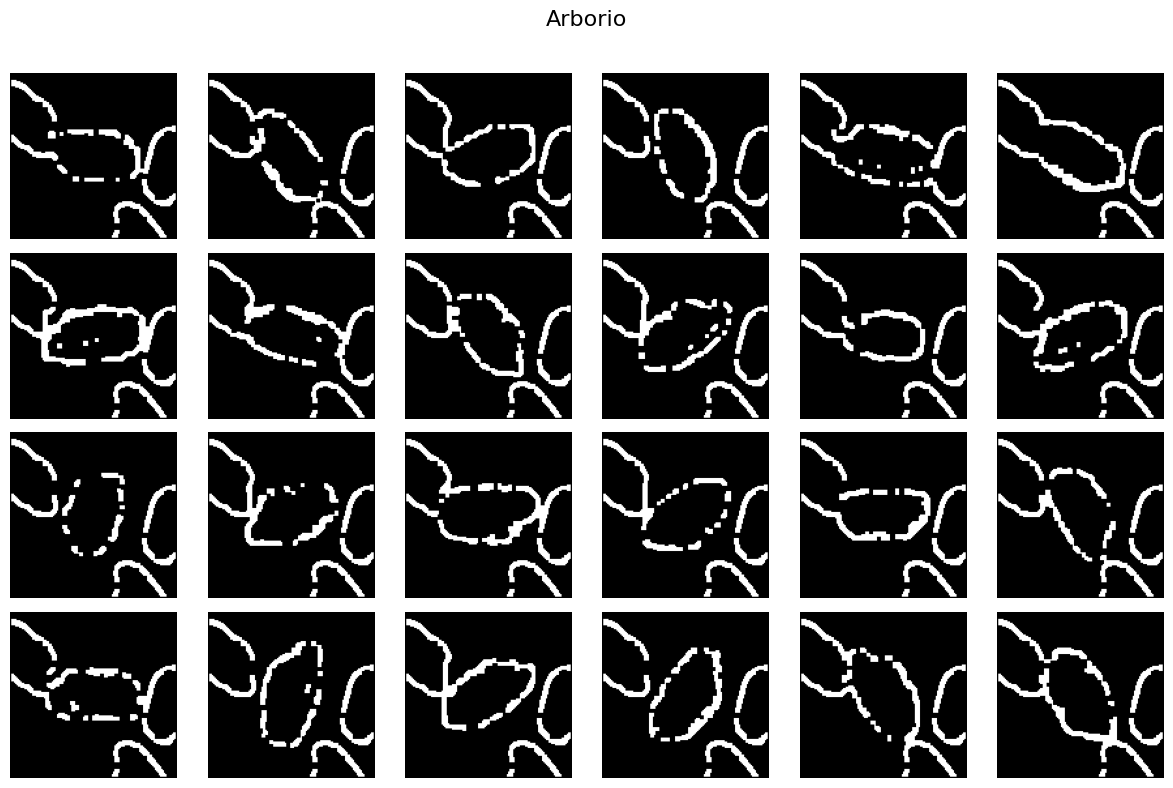

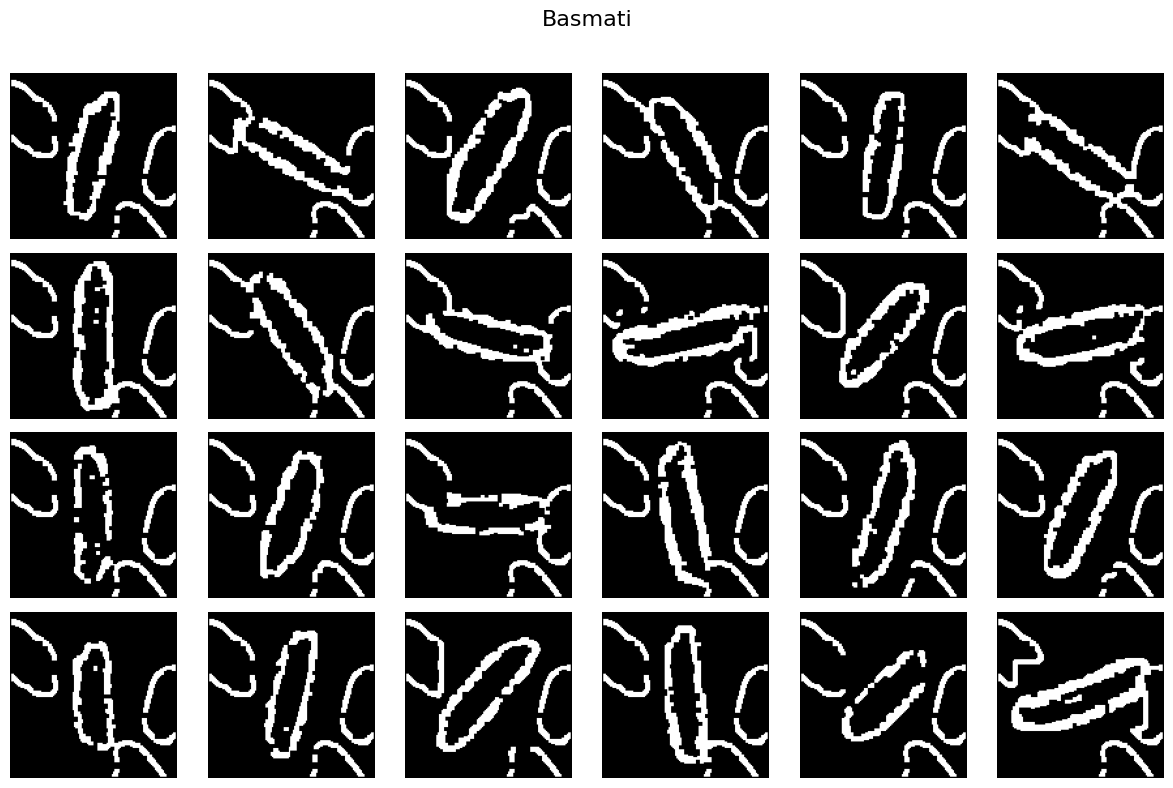

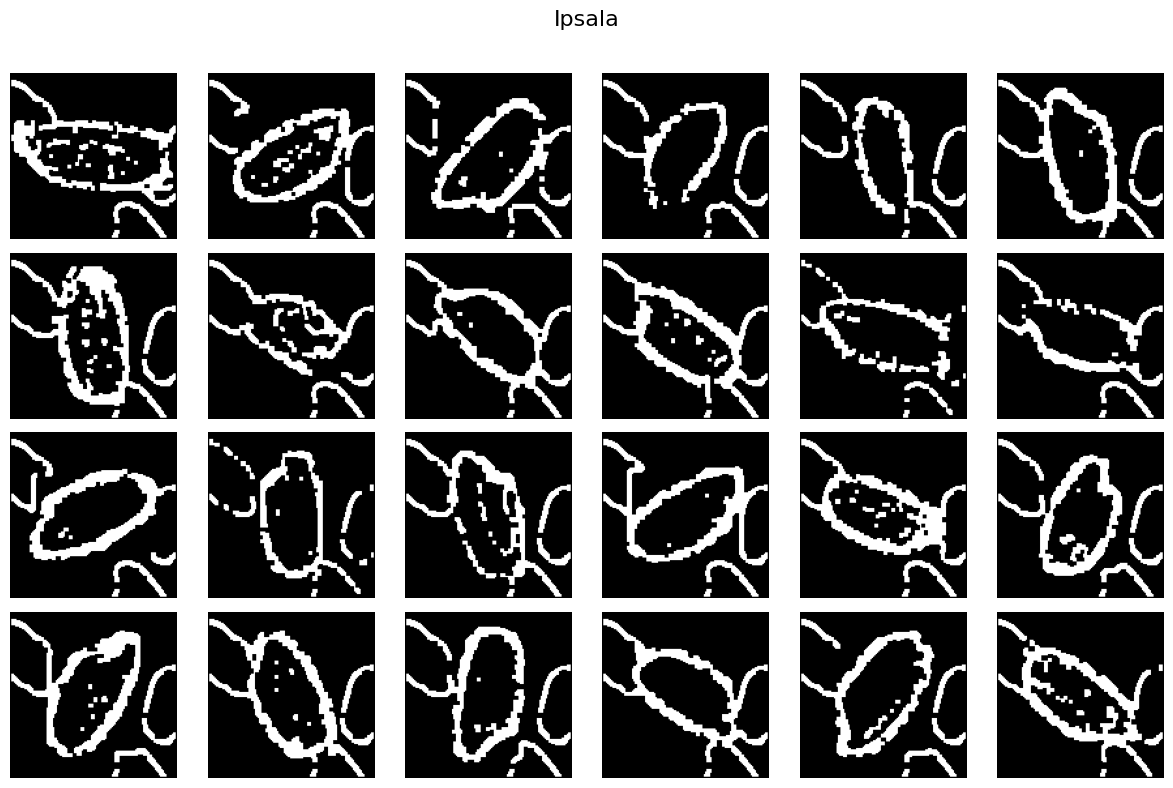

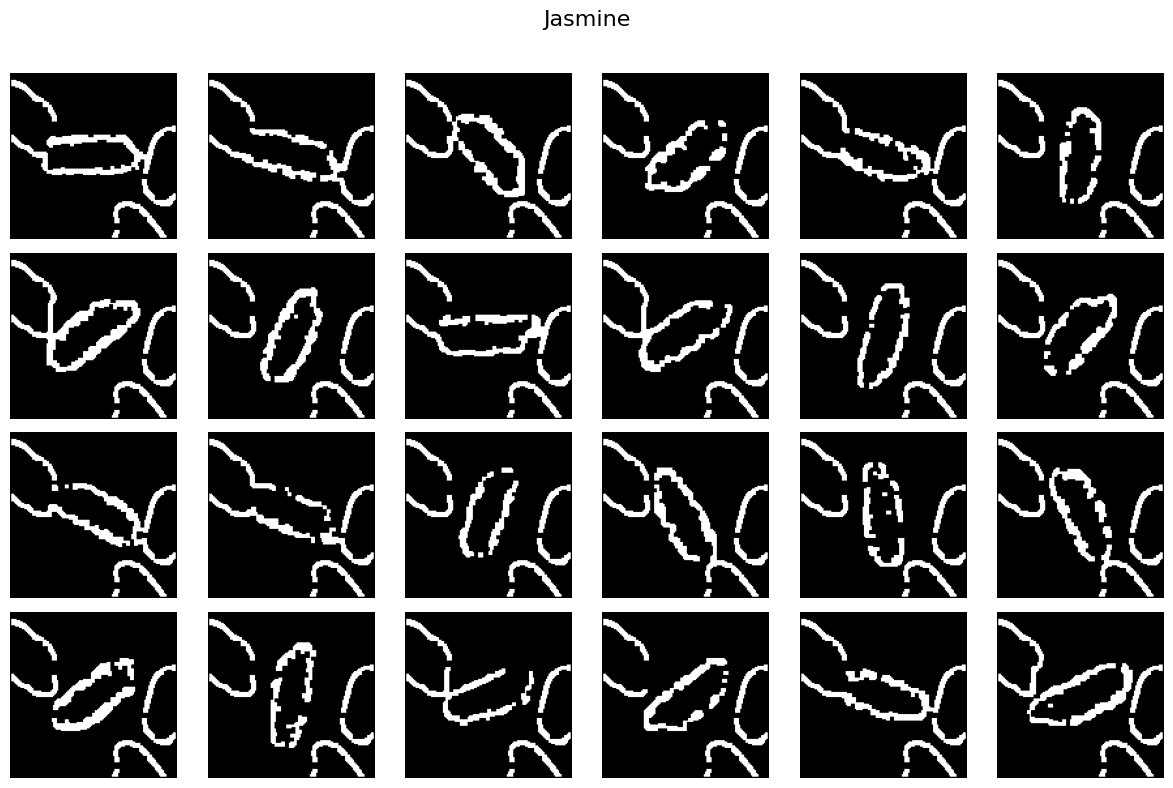

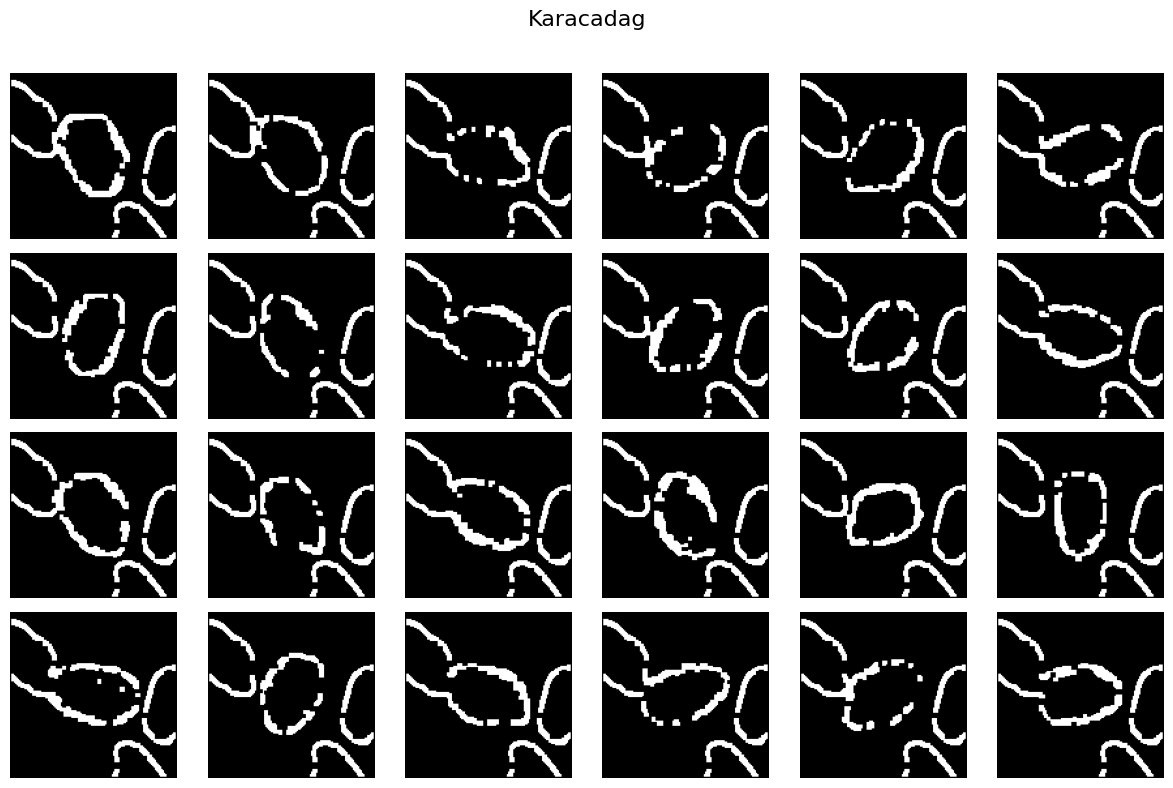

In [13]:
def percobaan4(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan4(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [14]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [15]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [17]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

In [18]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi4.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Arborio_1.jpg,Arborio,1872.028789,2693.080786,2128.032726,3426.824354,0.971211,0.958585,0.967274,0.947301,...,0.796726,0.777249,0.894662,0.887396,0.892595,0.881618,0.832248,0.760362,0.809308,0.695072
1,Arborio_2.jpg,Arborio,2144.032972,2781.775064,2264.034818,3797.727695,0.967028,0.957221,0.965183,0.941597,...,0.769842,0.747101,0.878387,0.872436,0.877407,0.864350,0.832246,0.783836,0.822856,0.704889
2,Arborio_3.jpg,Arborio,2200.033834,3176.867754,2264.034818,3539.707979,0.966167,0.951145,0.965183,0.945565,...,0.776201,0.757016,0.881543,0.872938,0.881023,0.870067,0.822109,0.744891,0.816934,0.715755
3,Arborio_4.jpg,Arborio,2416.037156,2999.479199,2056.031619,3813.853928,0.962845,0.953873,0.968381,0.941349,...,0.771010,0.745054,0.875131,0.869635,0.878072,0.863165,0.812696,0.769053,0.840606,0.706349
4,Arborio_5.jpg,Arborio,2056.031619,3039.794780,2432.037402,3805.790812,0.968381,0.953253,0.962599,0.941473,...,0.774579,0.754166,0.883155,0.874475,0.880102,0.868427,0.833072,0.754901,0.802545,0.693138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Karacadag_96.jpg,Karacadag,1800.027682,2523.755348,2136.032849,3386.508773,0.972318,0.961189,0.967151,0.947921,...,0.795714,0.776902,0.894745,0.888237,0.892028,0.881421,0.839539,0.776595,0.809586,0.700224
496,Karacadag_97.jpg,Karacadag,2232.034326,3136.552173,2112.032480,3499.392399,0.965675,0.951765,0.967520,0.946185,...,0.772598,0.751753,0.877995,0.869921,0.878976,0.867037,0.824847,0.755553,0.834264,0.727275
497,Karacadag_98.jpg,Karacadag,2184.033588,3233.309567,2328.035802,3636.465373,0.966413,0.950277,0.964198,0.944077,...,0.770367,0.750745,0.878879,0.869649,0.877706,0.866455,0.827855,0.746897,0.816505,0.715339
498,Karacadag_99.jpg,Karacadag,2136.032849,2822.090644,2232.034326,3700.970302,0.967151,0.956601,0.965675,0.943085,...,0.768387,0.746493,0.877362,0.871007,0.876577,0.863998,0.834483,0.782815,0.827044,0.715178


Fitur sebelum seleksi : 28
Fitur setelah seleksi : 9
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Entropy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


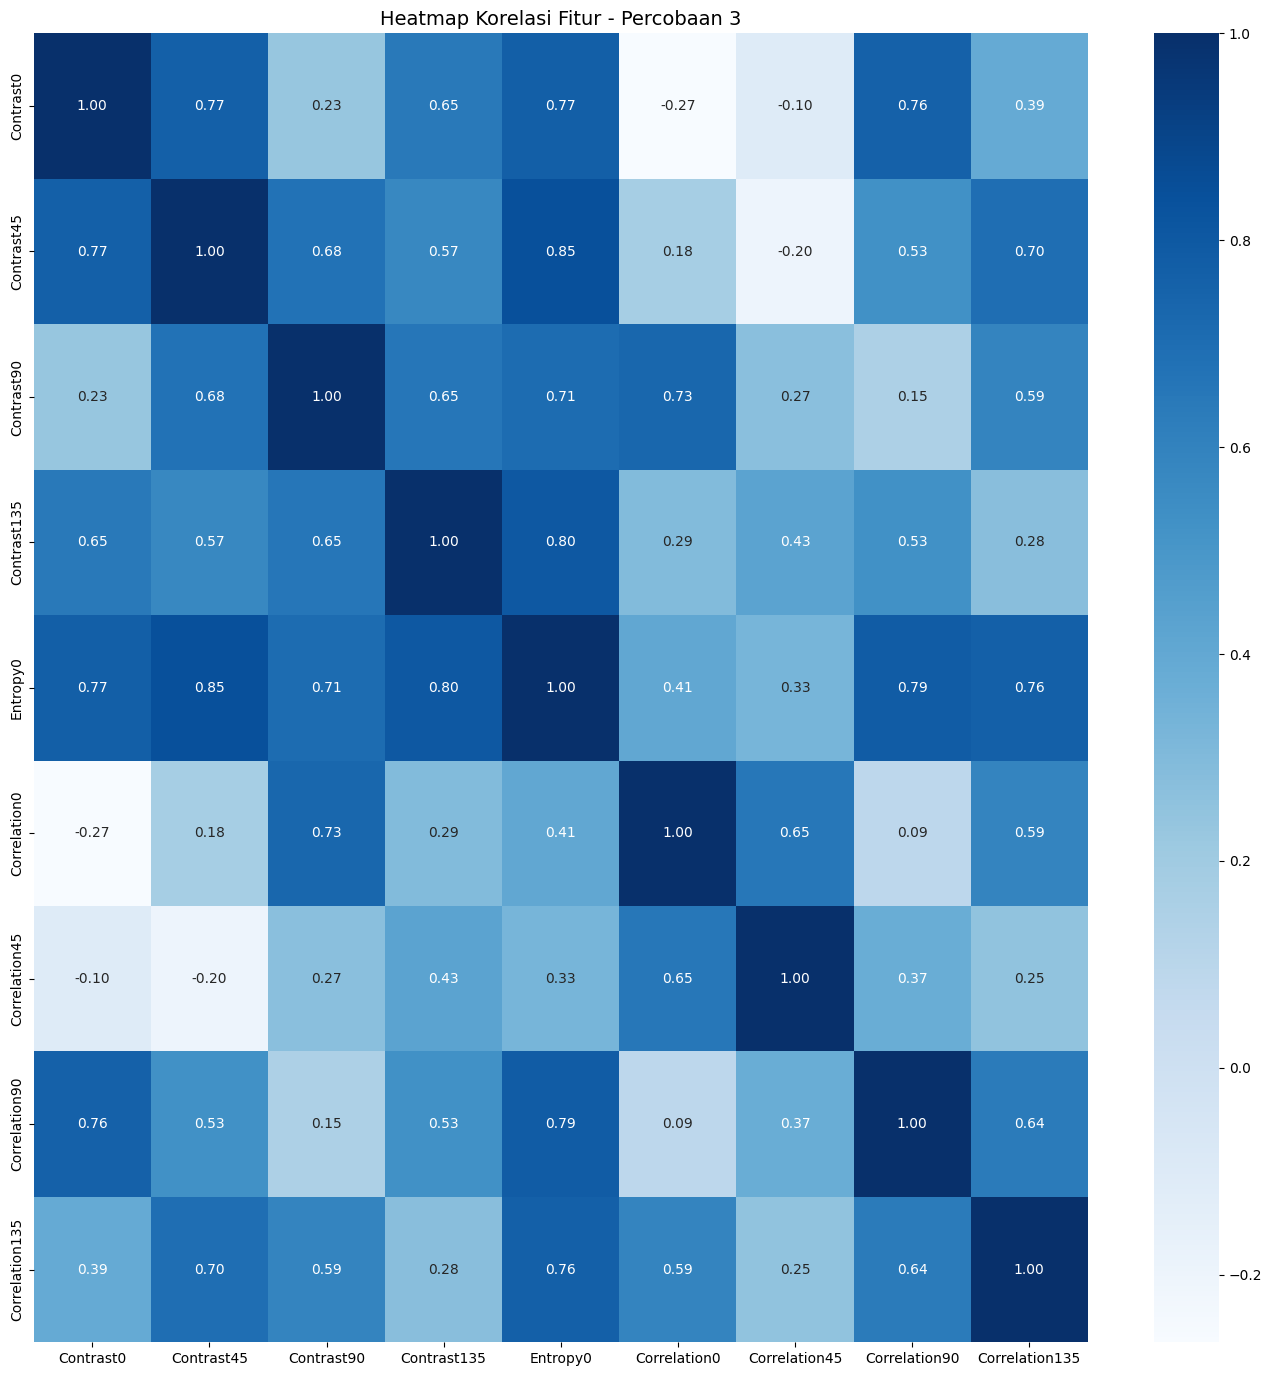

In [20]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

In [21]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(400, 9)
(100, 9)


In [22]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [23]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [24]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     Arborio       0.95      0.97      0.96        72
     Basmati       0.99      1.00      0.99        86
      Ipsala       1.00      0.99      0.99        90
     Jasmine       0.93      0.92      0.93        76
   Karacadag       0.97      0.96      0.97        76

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400

[[70  0  0  1  1]
 [ 0 86  0  0  0]
 [ 0  0 89  1  0]
 [ 4  1  0 70  1]
 [ 0  0  0  3 73]]
Accuracy: 0.97

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.59      0.68      0.63        28
     Basmati       0.78      1.00      0.88        14
      Ipsala       1.00      0.80      0.89        10
     Jasmine       0.50      0.42      0.45        24
   Karacadag       0.64      0.58      0.61        24

    accuracy                 

In [25]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       0.62      0.69      0.66        72
     Basmati       0.88      0.87      0.88        86
      Ipsala       0.94      0.88      0.91        90
     Jasmine       0.74      0.71      0.72        76
   Karacadag       0.73      0.75      0.74        76

    accuracy                           0.79       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.79      0.79      0.79       400

[[50  0  0  9 13]
 [ 1 75  5  5  0]
 [ 2  9 79  0  0]
 [13  1  0 54  8]
 [14  0  0  5 57]]
Accuracy: 0.7875

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.64      0.75      0.69        28
     Basmati       0.78      1.00      0.88        14
      Ipsala       0.88      0.70      0.78        10
     Jasmine       0.78      0.58      0.67        24
   Karacadag       0.74      0.71      0.72        24

    accuracy              

In [26]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     Arborio       0.65      0.79      0.71        72
     Basmati       0.89      0.90      0.89        86
      Ipsala       0.95      0.86      0.90        90
     Jasmine       0.80      0.79      0.79        76
   Karacadag       0.87      0.79      0.83        76

    accuracy                           0.83       400
   macro avg       0.83      0.82      0.83       400
weighted avg       0.84      0.83      0.83       400

[[57  0  0  8  7]
 [ 2 77  4  3  0]
 [ 4  9 77  0  0]
 [13  1  0 60  2]
 [12  0  0  4 60]]
Accuracy: 0.8275

------Testing Set------
              precision    recall  f1-score   support

     Arborio       0.62      0.75      0.68        28
     Basmati       0.78      1.00      0.88        14
      Ipsala       1.00      0.70      0.82        10
     Jasmine       0.67      0.50      0.57        24
   Karacadag       0.65      0.62      0.64        24

    accuracy              

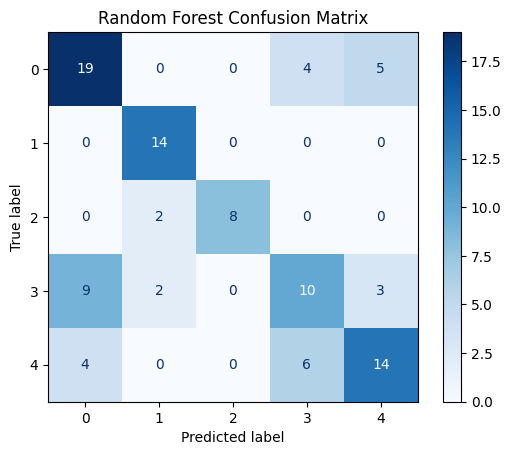

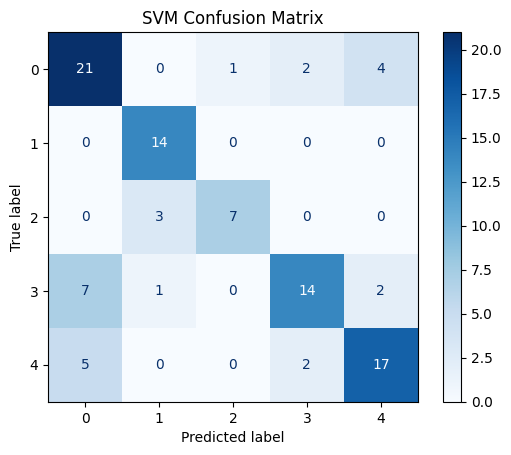

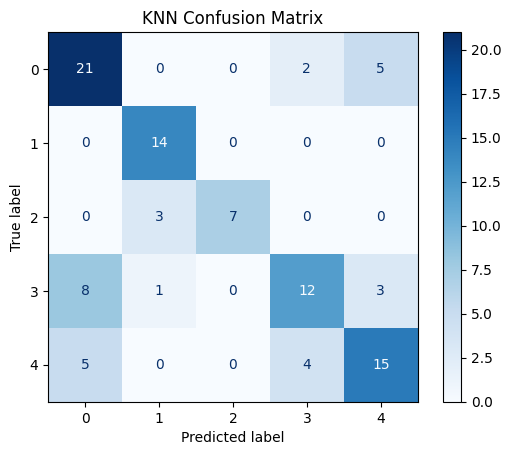

In [27]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

In [29]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./hasil_klasifikasi/hasil_klasifikasi4.csv', index=False)
print("✅ File hasil_klasifikasi4.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi4.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.9700,0.65,0.647866,0.65,0.643900
1,SVM,0.7875,0.73,0.738629,0.73,0.726682
2,KNN,0.8275,0.69,0.698352,0.69,0.684865
